# Assessment 2 — Machine Learning for Time Series Forecasting

## 1. Previous Descriptive Analysis and Results

In Assessment 1, a comprehensive exploratory data analysis of daily net retail sales from May 2000 to April 2003 was conducted, revealing significant **weekly** and **yearly** seasonality alongside high-amplitude volatility. A SARIMAX model was implemented to establish a statistical baseline for forecasting. While the model successfully captured the general sales level and the rhythmic weekly patterns, it struggled to accurately predict the magnitude of extreme sales spikes, resulting in a **MAPE of 49.13 %**, an **MAE of 121,217**, and an **RMSE of 149,494**. Residual diagnostics indicated that the linear model had not fully extracted all available signals, with errors concentrated around extreme events. These results highlight the limitations of purely statistical linear models when confronted with non-linear, event-driven data, providing a clear rationale for transitioning to the machine learning approaches explored in this assessment.

## 2. Data Preprocessing

### 2.1 Data Loading & Cleaning

We reproduce the exact preprocessing pipeline from Assessment 1 in a single consolidated cell:
1. Load the CSV and set a `DatetimeIndex` with daily frequency.
2. Trim the initial missing-data block (before 2000-07-10).
3. Impute the remaining gaps with linear interpolation.

Series range : 2000-07-10  →  2003-04-06
Total days   : 1001
Missing after imputation: 0


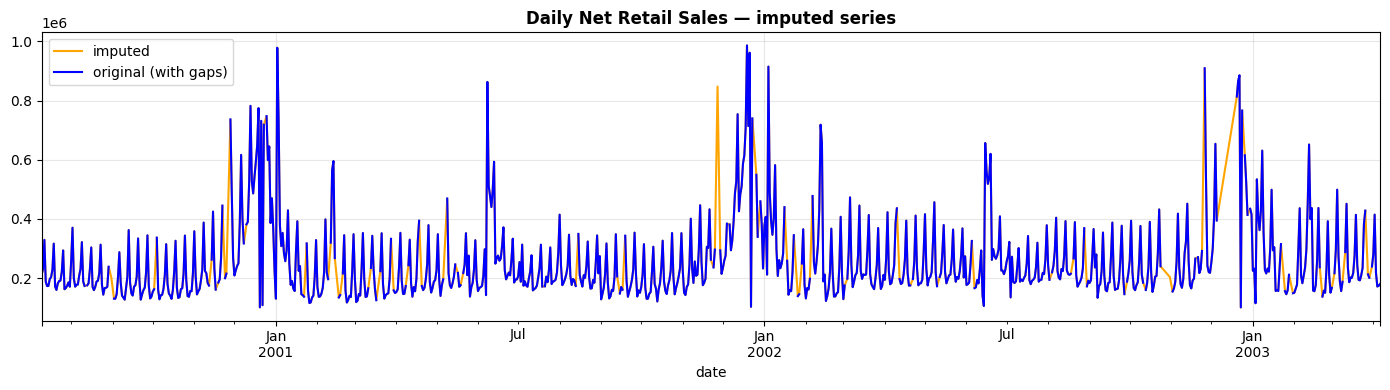

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load & basic cleaning ────────────────────────────────────────────────────
data_raw = pd.read_csv('07_Daily net retail sales. 5 May 2000 – 6 April 2003..csv')
data_raw['date'] = pd.to_datetime(data_raw['date'], format='%Y-%m-%d')
data_raw = data_raw.set_index('date').asfreq('D').sort_index()

# ── Trim the large initial missing block (as decided in Assessment 1) ─────────
data_trimmed = data_raw.loc['2000-07-10':].copy()

# ── Impute remaining gaps with linear interpolation ───────────────────────────
data_imputed = data_trimmed.copy()
data_imputed['sales'] = data_imputed['sales'].interpolate(method='linear')

print(f"Series range : {data_imputed.index.min().date()}  →  {data_imputed.index.max().date()}")
print(f"Total days   : {len(data_imputed)}")
print(f"Missing after imputation: {data_imputed['sales'].isna().sum()}")

# ── Quick visual confirmation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
data_imputed['sales'].plot(ax=ax, color='orange', label='imputed')
data_trimmed['sales'].plot(ax=ax, color='blue', label='original (with gaps)')
ax.set_title('Daily Net Retail Sales — imputed series', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Feature Engineering

For machine learning models we must convert the time series into a supervised-learning table.  
The features created are:

| Group | Features | Rationale |
|---|---|---|
| **Calendar** | day-of-week, month, quarter, is_weekend | Encode both weekly and yearly seasonality without requiring explicit seasonal differencing |
| **Lag** | lag 1, 7, 14 | Yesterday's sales, same weekday last week / two weeks ago — directly reflects the weekly cycle found in Assessment 1 |
| **Rolling** | 7-day and 30-day rolling mean & std | Capture short- and medium-term trend momentum; `shift(1)` prevents data leakage |

In [6]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add calendar, lag and rolling features to the sales dataframe."""
    df = df.copy()

    # Calendar features
    df['day_of_week'] = df.index.dayofweek          # 0 = Monday
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['is_weekend']  = df.index.dayofweek.isin([5, 6]).astype(int)

    # Lag features  (shift prevents any look-ahead)
    df['lag_1']  = df['sales'].shift(1)
    df['lag_7']  = df['sales'].shift(7)
    df['lag_14'] = df['sales'].shift(14)

    # Rolling statistics  (shift(1) inside to avoid leakage)
    s = df['sales'].shift(1)
    df['roll_mean_7']  = s.rolling(7).mean()
    df['roll_std_7']   = s.rolling(7).std()
    df['roll_mean_30'] = s.rolling(30).mean()

    return df

df_ml = create_features(data_imputed).dropna()

print(f"Shape after feature engineering: {df_ml.shape}")
display(df_ml.head())

Shape after feature engineering: (971, 11)


,sales,day_of_week,month,quarter,is_weekend,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7,roll_mean_30
date,,,,,,,,,,,
2000-08-09,321809.0,2,8,3,0,231602.0,370483.0,293742.0,219643.571429,69776.362604,210708.233333
2000-08-10,188905.0,3,8,3,0,321809.0,199677.0,162520.0,212690.142857,52534.488784,214333.933333
2000-08-11,173623.0,4,8,3,0,188905.0,171258.0,166537.0,211151.285714,53133.557562,212915.400000
2000-08-12,174696.0,5,8,3,1,173623.0,177883.0,174549.0,211489.142857,52844.344678,207723.666667
2000-08-13,175769.0,6,8,3,1,174696.0,178380.0,185984.0,211033.857143,53194.705430,207267.100000


### 2.3 Train / Test Split

We reserve the **final 90 days** as a hold-out test set, keeping it completely untouched until the final evaluation step.  
Model selection and hyperparameter tuning are performed exclusively on the training portion using **Time Series Cross-Validation (expanding window)**.

Train: 2000-08-09 → 2003-01-06  (n=881)
Test : 2003-01-07  → 2003-04-06   (n=90)


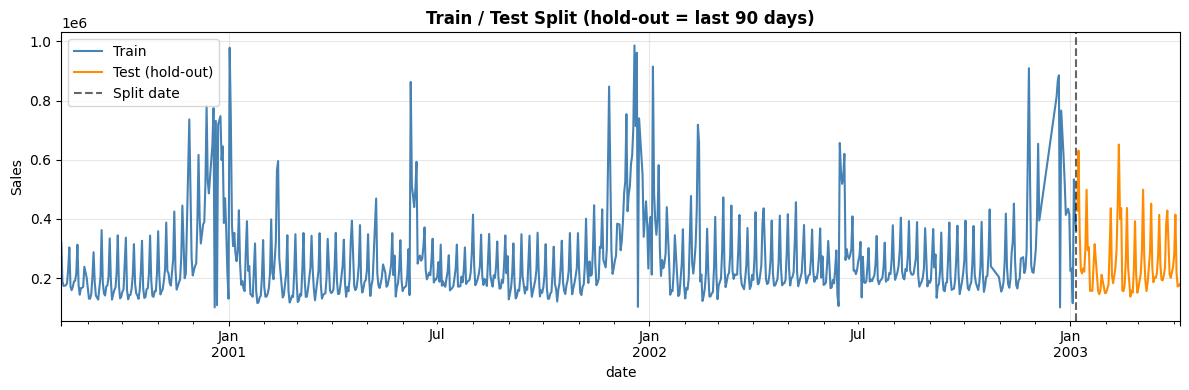

In [7]:
STEPS_TEST = 90

split_date = df_ml.index.max() - pd.Timedelta(days=STEPS_TEST)

train = df_ml.loc[df_ml.index <= split_date]
test  = df_ml.loc[df_ml.index >  split_date]

FEATURE_COLS = [c for c in df_ml.columns if c != 'sales']

X_train, y_train = train[FEATURE_COLS], train['sales']
X_test,  y_test  = test[FEATURE_COLS],  test['sales']

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  (n={len(train)})")
print(f"Test : {test.index.min().date()}  → {test.index.max().date()}   (n={len(test)})")

# ── Plot the split ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
y_train.plot(ax=ax, label='Train', color='steelblue')
y_test.plot(ax=ax,  label='Test (hold-out)', color='darkorange')
ax.axvline(split_date, color='black', linestyle='--', alpha=0.6, label='Split date')
ax.set_title('Train / Test Split (hold-out = last 90 days)', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Model Selection and Fitting

### 3.1a Linear Model — Ridge Regression

**Rationale:** Ridge regression is the regularised linear baseline. It is fast, interpretable, and provides a ceiling for "how well can a purely linear model do with our engineered features?". The regularisation parameter `alpha` is tuned via cross-validation.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/7 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'ridge__alpha': 1e-10}
  Backtesting metric: 83056.59801540917

Top 3 Ridge configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label                   params  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 1e-10}   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 1e-08}   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 1e-06}   

   mean_absolute_error  ridge__alpha  
0         83056.598015  1.000000e-10  
1         83056.598016  1.000000e-08  
2         83056.598037  1.000000e-06  

Ridge  →  MAE: 112,605   MAPE: 52.6%


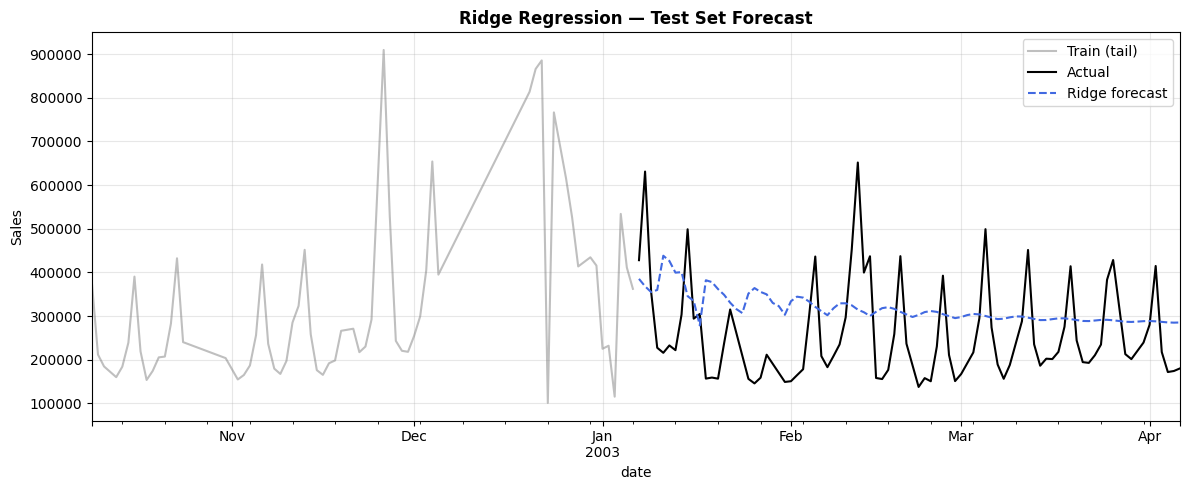

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster, TimeSeriesFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ── Forecaster ────────────────────────────────────────────────────────────────
pipe_ridge = make_pipeline(StandardScaler(), Ridge())
forecaster_ridge = ForecasterRecursive(regressor=pipe_ridge, lags=14)

# param_grid_ridge = {'ridge__alpha': np.logspace(-3, 3, 10)}
param_grid_ridge = {'ridge__alpha': [1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 0.1, 1.0]}

cv = TimeSeriesFold(
    steps=STEPS_TEST,
    initial_train_size=len(y_train) - 180,
    fold_stride=30,
    refit=True,
    fixed_train_size=False,
    gap=0,
    allow_incomplete_fold=True
)

results_ridge = grid_search_forecaster(
    forecaster=forecaster_ridge,
    y=y_train,
    param_grid=param_grid_ridge,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Ridge configurations:")
print(results_ridge.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_ridge = forecaster_ridge.predict(steps=STEPS_TEST)
mae_ridge  = mean_absolute_error(y_test, pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, pred_ridge)
print(f"\nRidge  →  MAE: {mae_ridge:,.0f}   MAPE: {mape_ridge:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_ridge.plot(ax=ax,       color='royalblue',  ls='--',  label='Ridge forecast')
ax.set_title('Ridge Regression — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1b Linear Model — Lasso Regression

**Rationale:** Lasso applies an L1 penalty instead of Ridge's L2, which drives some feature coefficients exactly to zero. This makes it useful as a feature-selection diagnostic: if Lasso performs similarly to Ridge but zeroes out certain lags or calendar features, it tells us those features carry little predictive signal for this series.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/10 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'lasso__alpha': np.float64(0.001)}
  Backtesting metric: 83056.5985747265

Top 3 Lasso configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                   params  mean_absolute_error  lasso__alpha  
0                 {'lasso__alpha': 0.001}         83056.598575      0.001000  
1  {'lasso__alpha': 0.004641588833612777}         83056.600592      0.004642  
2  {'lasso__alpha': 0.021544346900318832}         83056.609776      0

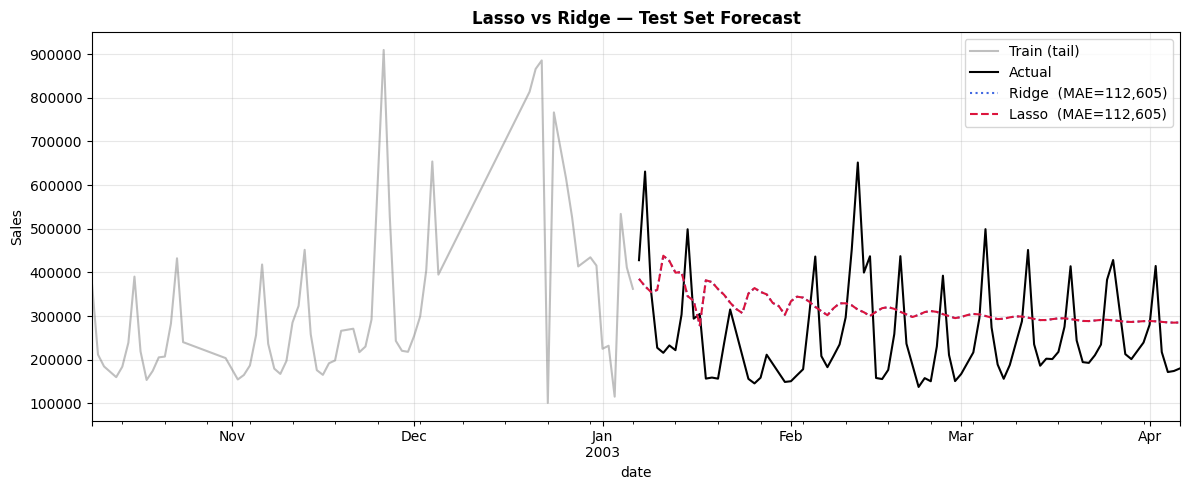

In [17]:
from sklearn.linear_model import Lasso

# ── Forecaster ────────────────────────────────────────────────────────────────
pipe_lasso = make_pipeline(StandardScaler(), Lasso(max_iter=10_000))
forecaster_lasso = ForecasterRecursive(regressor=pipe_lasso, lags=14)

param_grid_lasso = {'lasso__alpha': np.logspace(-3, 3, 10)}

results_lasso = grid_search_forecaster(
    forecaster=forecaster_lasso,
    y=y_train,
    param_grid=param_grid_lasso,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Lasso configurations:")
print(results_lasso.head(3))
best_lasso_alpha = results_lasso.iloc[0]['lasso__alpha']

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_lasso = forecaster_lasso.predict(steps=STEPS_TEST)
mae_lasso  = mean_absolute_error(y_test, pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, pred_lasso)
print(f"\nLasso (alpha={best_lasso_alpha:.4f})  ->  MAE: {mae_lasso:,.0f}   MAPE: {mape_lasso:.1%}")
print(f"Ridge comparison                      ->  MAE: {mae_ridge:,.0f}   MAPE: {mape_ridge:.1%}")

# ── Coefficient sparsity ──────────────────────────────────────────────────────
lasso_coefs = forecaster_lasso.regressor.named_steps['lasso'].coef_
n_zero = (lasso_coefs == 0).sum()
print(f"\nZeroed-out coefficients: {n_zero} / {len(lasso_coefs)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_ridge.plot(ax=ax,       color='royalblue', ls=':',   label=f'Ridge  (MAE={mae_ridge:,.0f})')
pred_lasso.plot(ax=ax,       color='crimson',   ls='--',  label=f'Lasso  (MAE={mae_lasso:,.0f})')
ax.set_title('Lasso vs Ridge — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 3.2 Tree-Based Models

#### 3.2.1 Random Forest

**Rationale:** Random Forest is an ensemble of decision trees trained on bootstrap samples. It handles non-linear relationships and interaction effects naturally (important for capturing the interplay between day-of-week and month during holiday periods) without requiring normalisation.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/12 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}
  Backtesting metric: 54185.52815385577

Top 3 Random Forest configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'max_depth': 10, 'min_samples_leaf': 1, 'n_es...         54185.528154   
1  {'max_depth': None, 'min_samples_leaf': 1, 'n_...         57468.131034   
2  {'max_depth': 10, 'min_samples_leaf':

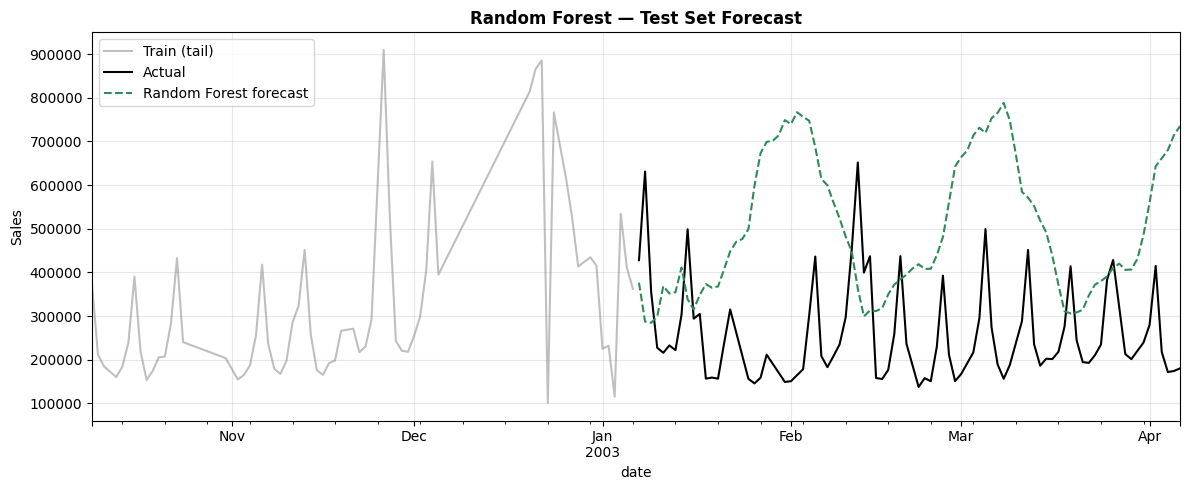

In [9]:
from sklearn.ensemble import RandomForestRegressor

forecaster_rf = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=42, n_jobs=-1),
    lags=14
)

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth':    [5, 10, None],
    'min_samples_leaf': [1, 5]
}

results_rf = grid_search_forecaster(
    forecaster=forecaster_rf,
    y=y_train,
    param_grid=param_grid_rf,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Random Forest configurations:")
print(results_rf.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_rf   = forecaster_rf.predict(steps=STEPS_TEST)
mae_rf    = mean_absolute_error(y_test, pred_rf)
mape_rf   = mean_absolute_percentage_error(y_test, pred_rf)
print(f"\nRandom Forest  →  MAE: {mae_rf:,.0f}   MAPE: {mape_rf:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_rf.plot(ax=ax,          color='seagreen',  ls='--',  label='Random Forest forecast')
ax.set_title('Random Forest — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.2.2 XGBoost

**Rationale:** XGBoost builds trees sequentially, with each tree correcting the residuals of the previous one. It typically outperforms Random Forest on tabular data and is especially effective when the error distribution is heavy-tailed — exactly the situation we face with extreme sales spikes.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/16 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}
  Backtesting metric: 54184.714112103175

Top 3 XGBoost configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'learning_rate': 0.1, 'max_depth': 6, 'n_esti...         54184.714112   
1  {'learning_rate': 0.05, 'max_depth': 3, 'n_est...         57298.621230   
2  {'learning_rate': 0.1, 'ma

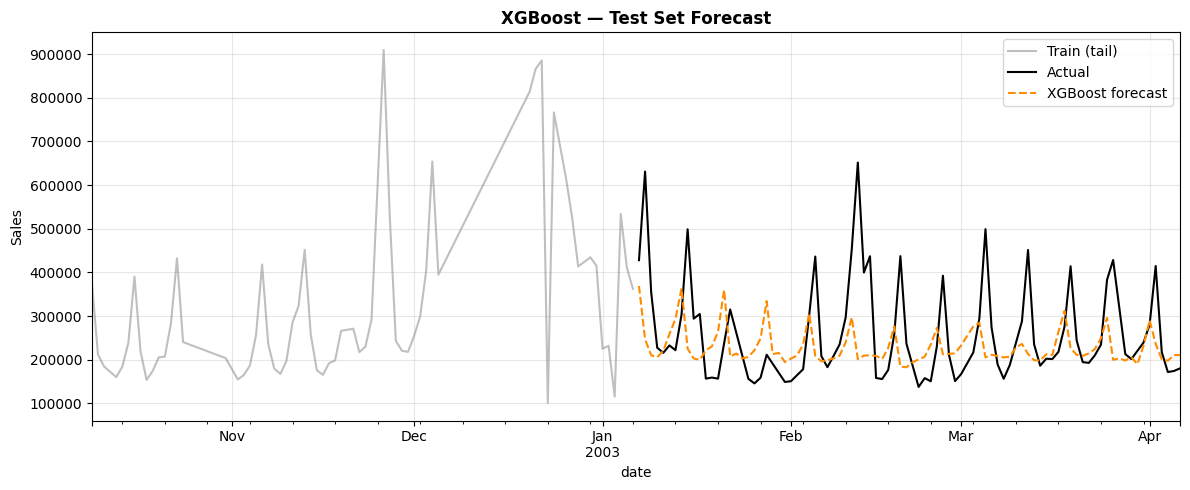

In [10]:
from xgboost import XGBRegressor

forecaster_xgb = ForecasterRecursive(
    regressor=XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    lags=14
)

param_grid_xgb = {
    'n_estimators':  [200, 500],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

results_xgb = grid_search_forecaster(
    forecaster=forecaster_xgb,
    y=y_train,
    param_grid=param_grid_xgb,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 XGBoost configurations:")
print(results_xgb.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_xgb  = forecaster_xgb.predict(steps=STEPS_TEST)
mae_xgb   = mean_absolute_error(y_test, pred_xgb)
mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
print(f"\nXGBoost  →  MAE: {mae_xgb:,.0f}   MAPE: {mape_xgb:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_xgb.plot(ax=ax,         color='darkorange', ls='--',  label='XGBoost forecast')
ax.set_title('XGBoost — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.3 Prophet

**Rationale:** Prophet (Meta, 2017) is purpose-built for business time series. It decomposes the signal into trend + seasonality + holidays, fits each component separately, and is robust to missing data and outliers. It is a natural candidate for retail sales with multiple overlapping seasonalities.

Importing plotly failed. Interactive plots will not work.
22:20:27 - cmdstanpy - INFO - Chain [1] start processing
22:20:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet  →  MAE: 45,676   MAPE: 18.5%


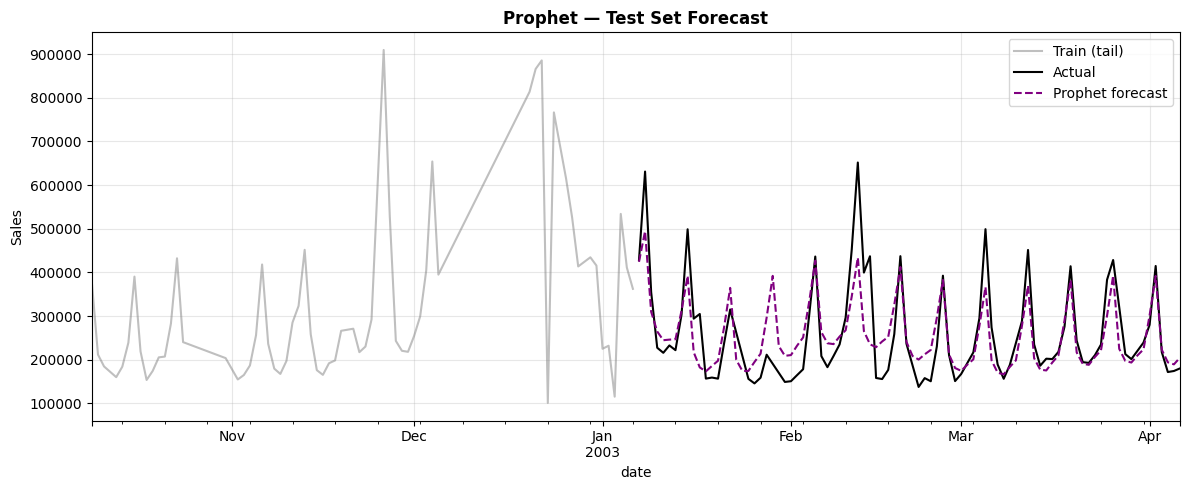

In [11]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Prophet requires a dataframe with columns 'ds' and 'y'
df_prophet_train = y_train.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet_test  = y_test.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# ── Fit ───────────────────────────────────────────────────────────────────────
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # sales spikes scale with the level
    changepoint_prior_scale=0.05
)
prophet_model.fit(df_prophet_train)

# ── Forecast ──────────────────────────────────────────────────────────────────
future     = prophet_model.make_future_dataframe(periods=STEPS_TEST)
forecast_p = prophet_model.predict(future)

# Align to test index
pred_prophet = (
    forecast_p.set_index('ds')['yhat']
    .loc[y_test.index]
)
pred_prophet.index.freq = None  # avoid freq mismatch warnings

mae_prophet  = mean_absolute_error(y_test, pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_test, pred_prophet)
print(f"Prophet  →  MAE: {mae_prophet:,.0f}   MAPE: {mape_prophet:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',     alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',    lw=1.5,   label='Actual')
pred_prophet.plot(ax=ax,     color='purple',   ls='--',  label='Prophet forecast')
ax.set_title('Prophet — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.4 Hybrid Methods

#### 3.4.1 Residual Boosting (SARIMAX + XGBoost)

**Rationale:** The SARIMAX model from Assessment 1 is excellent at capturing linear structure and weekly periodicity, but its residuals are non-normal and autocorrelated. We use XGBoost to learn the *residuals* of SARIMAX — a classic two-stage hybrid that combines the interpretability of a statistical model with the non-linear power of gradient boosting.

Fitting SARIMAX (stage 1) ...
SARIMAX order: (2, 0, 1) × (2, 0, 1, 7)

Hybrid (SARIMAX + XGBoost residuals)  →  MAE: 432,776   MAPE: 172.0%


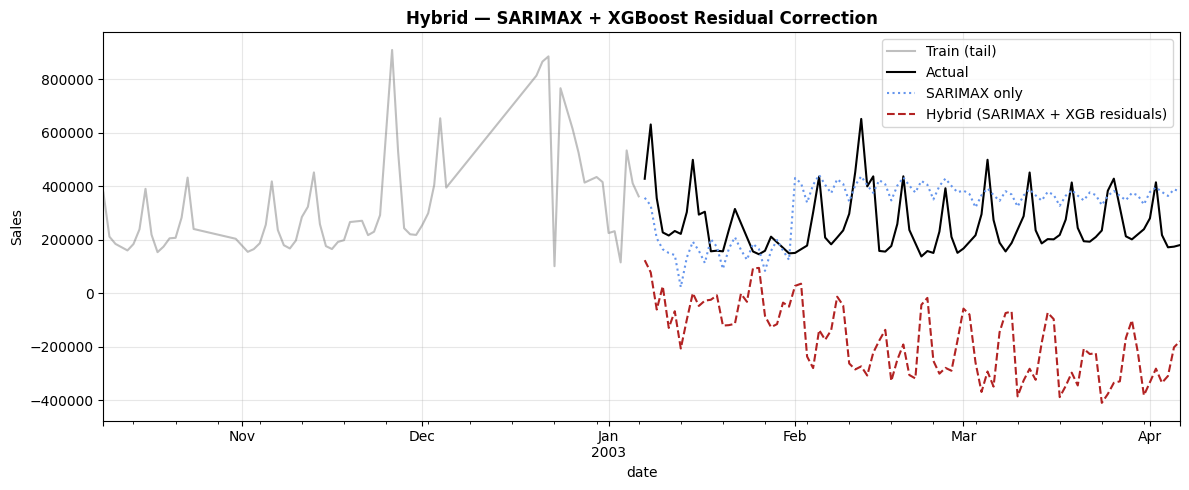

In [12]:
import pmdarima as pm

# ── Stage 1: fit SARIMAX on training data ─────────────────────────────────────
# Monthly exogenous dummies (same setup as Assessment 1)
def make_exog(index):
    exog = pd.DataFrame(index=index)
    for m in range(2, 13):
        exog[f'month_{m}'] = (index.month == m).astype(int)
    return exog

exog_train_s = make_exog(y_train.index)
exog_test_s  = make_exog(y_test.index)

print("Fitting SARIMAX (stage 1) ...")
sarimax_model = pm.auto_arima(
    y=y_train,
    X=exog_train_s,
    seasonal=True, m=7,
    d=0, D=None,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    information_criterion='aic',
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(f"SARIMAX order: {sarimax_model.order} × {sarimax_model.seasonal_order}")

# ── In-sample SARIMAX fitted values → compute training residuals ──────────────
fitted_train    = pd.Series(sarimax_model.fittedvalues(), index=y_train.index)
residuals_train = y_train - fitted_train

# ── Stage 2: XGBoost on SARIMAX residuals ─────────────────────────────────────
# Build features for the residuals series
df_res = create_features(residuals_train.rename('sales').to_frame()).dropna()
X_res_train = df_res.drop('sales', axis=1)
y_res_train = df_res['sales']

xgb_residual = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, objective='reg:squarederror',
    random_state=42, verbosity=0
)
xgb_residual.fit(X_res_train, y_res_train)

# ── Test-set forecast ─────────────────────────────────────────────────────────
sarimax_pred_test = pd.Series(
    sarimax_model.predict(n_periods=STEPS_TEST, X=exog_test_s),
    index=y_test.index
)

# Build features for the test window (using full imputed series for context)
df_full_for_res = create_features(data_imputed.copy()).dropna()
X_test_res = df_full_for_res.loc[y_test.index, FEATURE_COLS]
residual_correction = pd.Series(xgb_residual.predict(X_test_res), index=y_test.index)

pred_hybrid_residual = sarimax_pred_test + residual_correction

mae_hybrid_res  = mean_absolute_error(y_test, pred_hybrid_residual)
mape_hybrid_res = mean_absolute_percentage_error(y_test, pred_hybrid_residual)
print(f"\nHybrid (SARIMAX + XGBoost residuals)  →  MAE: {mae_hybrid_res:,.0f}   MAPE: {mape_hybrid_res:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',    alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',   lw=1.5,   label='Actual')
sarimax_pred_test.plot(ax=ax,      color='cornflowerblue', ls=':',  label='SARIMAX only')
pred_hybrid_residual.plot(ax=ax,   color='firebrick',      ls='--', label='Hybrid (SARIMAX + XGB residuals)')
ax.set_title('Hybrid — SARIMAX + XGBoost Residual Correction', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

#### 3.4.2 Weighted Ensemble

**Rationale:** Rather than picking a single "best" model, we combine the predictions of the three ML models (Ridge, Random Forest, XGBoost) using inverse-MAE weighting. Models with lower validation error receive a higher weight. This typically reduces variance and provides more stable forecasts across different time periods.

Ensemble weights (inverse-MAE):
  ridge     : 0.246   (CV MAE = 83,057)
  rf        : 0.377   (CV MAE = 54,186)
  xgb       : 0.377   (CV MAE = 54,185)

Weighted Ensemble  →  MAE: 145,278   MAPE: 69.7%


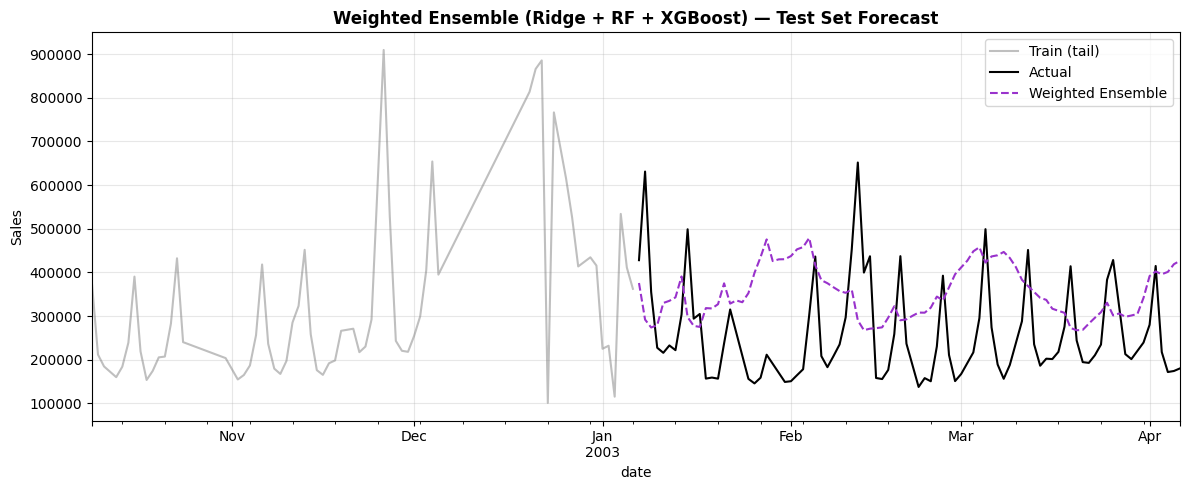

In [14]:
# ── Inverse-MAE weights (computed on cross-validated scores) ──────────────────
cv_mae = {
    'ridge': results_ridge.iloc[0]['mean_absolute_error'],
    'rf':    results_rf.iloc[0]['mean_absolute_error'],
    'xgb':  results_xgb.iloc[0]['mean_absolute_error']
}
inv_mae    = {k: 1.0 / v for k, v in cv_mae.items()}
total_inv  = sum(inv_mae.values())
weights    = {k: v / total_inv for k, v in inv_mae.items()}

print("Ensemble weights (inverse-MAE):")
for m, w in weights.items():
    print(f"  {m:10s}: {w:.3f}   (CV MAE = {cv_mae[m]:,.0f})")

# ── Combine predictions ───────────────────────────────────────────────────────
pred_ensemble = (
      weights['ridge'] * pred_ridge.values
    + weights['rf']    * pred_rf.values
    + weights['xgb']   * pred_xgb.values
)
pred_ensemble = pd.Series(pred_ensemble, index=y_test.index)

mae_ensemble  = mean_absolute_error(y_test, pred_ensemble)
mape_ensemble = mean_absolute_percentage_error(y_test, pred_ensemble)
print(f"\nWeighted Ensemble  →  MAE: {mae_ensemble:,.0f}   MAPE: {mape_ensemble:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_ensemble.plot(ax=ax,    color='darkorchid', ls='--',  label='Weighted Ensemble')
ax.set_title('Weighted Ensemble (Ridge + RF + XGBoost) — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Model Validation and Predictive Quality

We now compare all models head-to-head on the same 90-day hold-out test set using three metrics:

| Metric | Formula | What it measures |
|---|---|---|
| **MAE** | mean\|y − ŷ\| | Average absolute error in the same units as sales |
| **RMSE** | √mean(y−ŷ)² | Penalises large spikes more heavily than MAE |
| **MAPE** | mean\|y−ŷ\|/y × 100 | Scale-free; intuitive as a % deviation |

FINAL MODEL COMPARISON — Hold-out Test Set (90 days)


,MAE,RMSE,MAPE (%)
Model,,,
Prophet,45676.000000,63850.000000,18.490000
XGBoost,76424.000000,114746.000000,26.380000
Lasso Regression,112605.000000,128543.000000,52.590000
Ridge Regression,112605.000000,128543.000000,52.590000
Weighted Ensemble,145278.000000,166545.000000,69.710000
Random Forest,273613.000000,323920.000000,135.410000
Hybrid (SARIMAX + XGBoost),432776.000000,471674.000000,171.980000


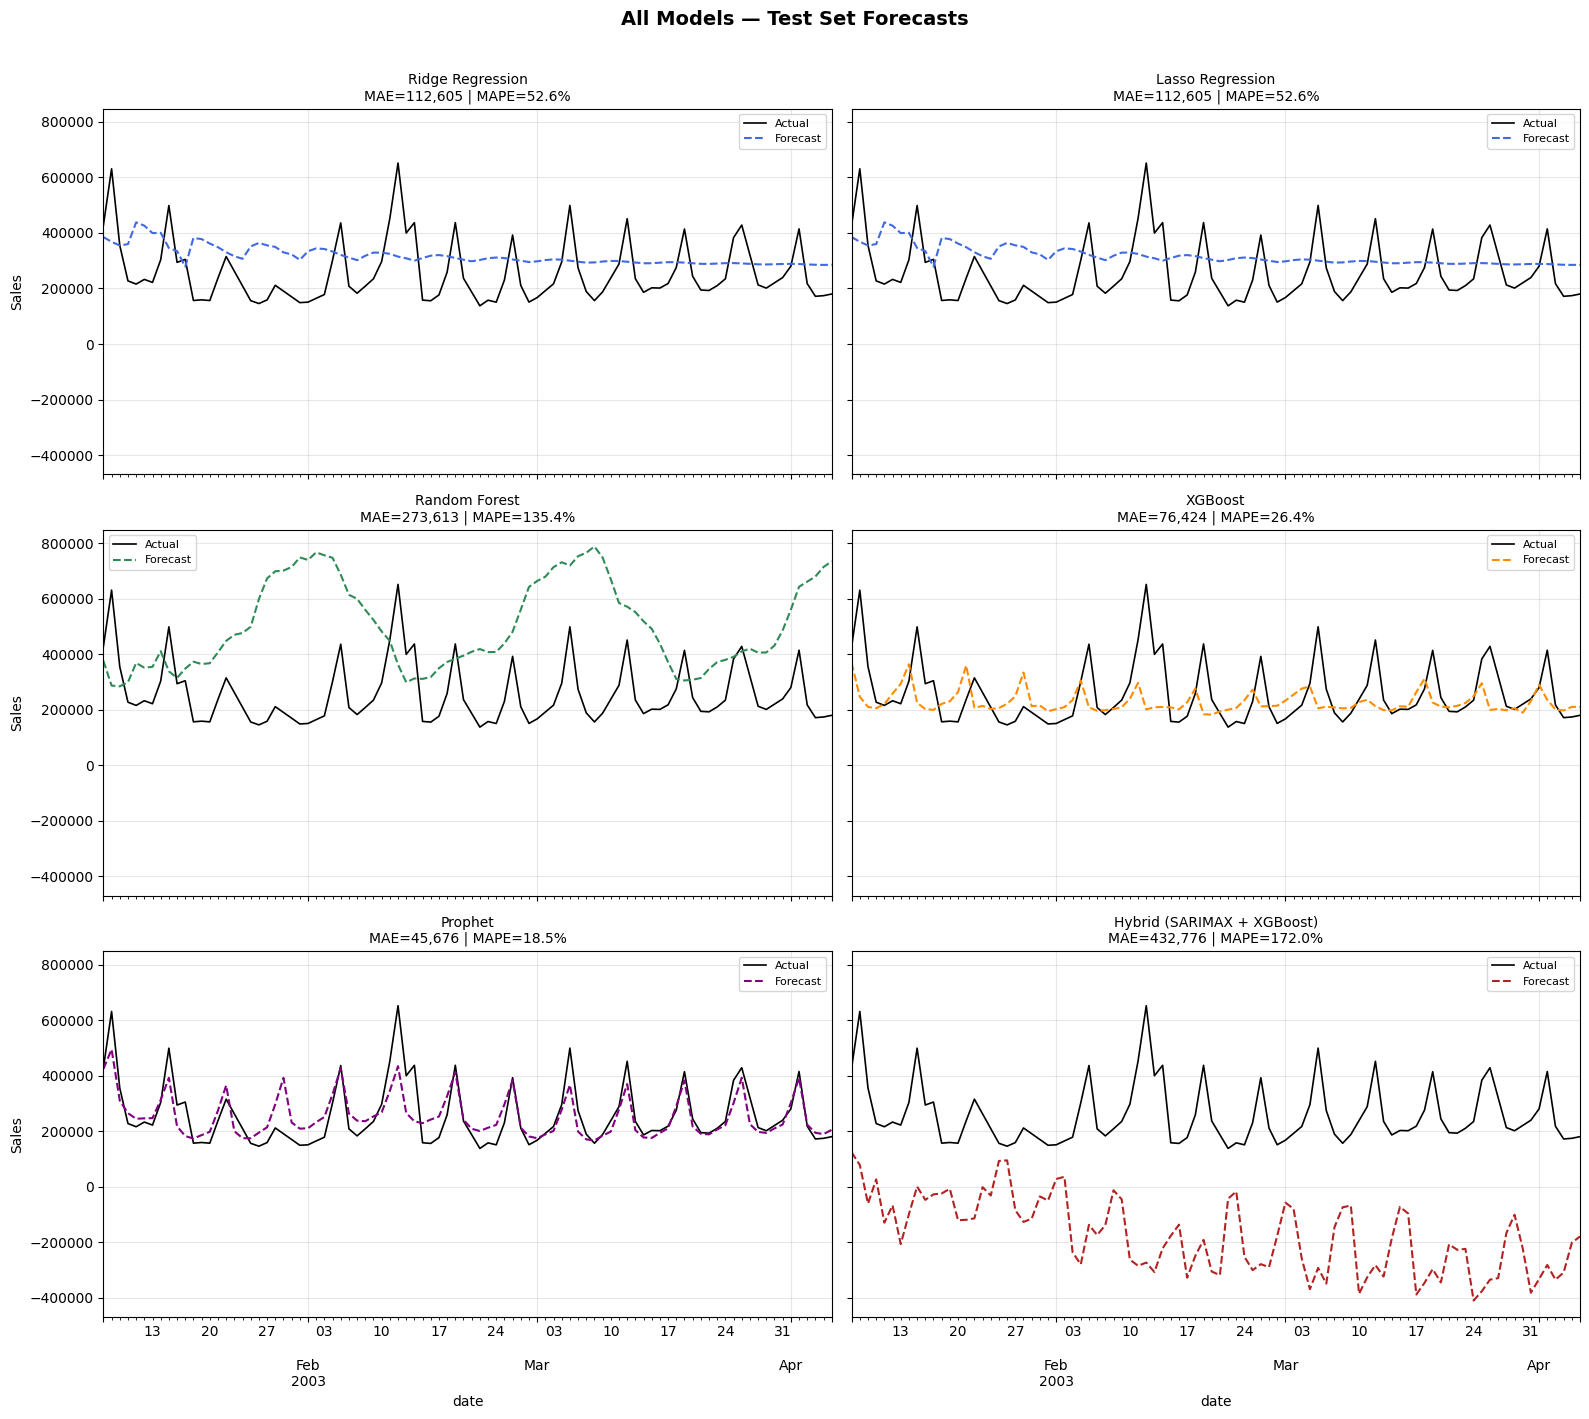

In [ ]:
from sklearn.metrics import mean_squared_error

def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'Model': name, 'MAE': round(mae, 0), 'RMSE': round(rmse, 0), 'MAPE (%)': round(mape, 2)}

results_table = pd.DataFrame([
    eval_metrics(y_test, pred_ridge,           'Ridge Regression'),
    eval_metrics(y_test, pred_rf,              'Random Forest'),
    eval_metrics(y_test, pred_xgb,             'XGBoost'),
    eval_metrics(y_test, pred_prophet,         'Prophet'),
    eval_metrics(y_test, pred_hybrid_residual, 'Hybrid (SARIMAX + XGBoost)'),
    eval_metrics(y_test, pred_ensemble,        'Weighted Ensemble'),
]).set_index('Model').sort_values('MAE')

print("=" * 55)
print("FINAL MODEL COMPARISON — Hold-out Test Set (90 days)")
print("=" * 55)
display(results_table.style.highlight_min(color='lightgreen', axis=0))

# ── Side-by-side forecast plot ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()

models = [
    ('Ridge Regression',              pred_ridge,           'royalblue'),
    ('Random Forest',                 pred_rf,              'seagreen'),
    ('XGBoost',                       pred_xgb,             'darkorange'),
    ('Prophet',                       pred_prophet,         'purple'),
    ('Hybrid (SARIMAX + XGBoost)',    pred_hybrid_residual, 'firebrick'),
    ('Weighted Ensemble',             pred_ensemble,        'darkorchid'),
]

for ax, (title, preds, color) in zip(axes, models):
    y_test.plot(ax=ax, color='black', lw=1.2, label='Actual')
    preds.plot(ax=ax, color=color, ls='--', lw=1.5, label='Forecast')
    mae_v  = mean_absolute_error(y_test, preds)
    mape_v = mean_absolute_percentage_error(y_test, preds) * 100
    ax.set_title(f"{title}\nMAE={mae_v:,.0f} | MAPE={mape_v:.1f}%", fontsize=10)
    ax.set_ylabel('Sales')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('All Models — Test Set Forecasts', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Conclusions

